In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

\begin{tabular}{llll}
\toprule
 & params & R2 & MAE \\
model &  &  &  \\
\midrule
GLM & 28 (0) & 0.270 (0.003) & 2.938 (0.019) \\
Sparse & 45 (3) & 0.399 (0.004) & 2.636 (0.007) \\
NN & 73000 (0) & 0.645 (0.014) & 2.038 (0.054) \\
\bottomrule
\end{tabular}



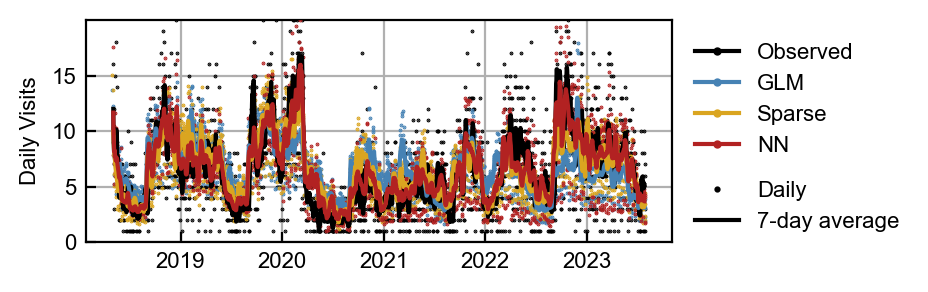

In [60]:
from sklearn.metrics import r2_score, mean_absolute_error
from airquality.analysis.postprocessing import aggregate_n_params, aggregate_predictions
from airquality.analysis.plotting import plot_aggregate_predictions
from airquality.analysis.postprocessing.aggregate import iqr_score

from matplotlib.lines import Line2D


score_funcs = {
    'R2': r2_score,
    'MAE': mean_absolute_error,
}

plt.rcParams['font.size'] = 8

def plot_seven_day_rolling_average(ax, df, color):
    ax.plot(df.index.to_timestamp(), df.values, zorder=5, 
            linestyle='', marker='.', markersize=0.75, color=color)

    rolling = df.rolling(window=7, center=True).mean()
    ax.plot(rolling.index.to_timestamp(), rolling.values, zorder=10, 
            linewidth=1.5, color=color)


def predictions_figure(info, socio_var, remove_outliers=False):
    fig, ax = plt.subplots(1, 1, dpi=200, figsize=(3.5, 1.5))

    plot_observed = True
    model_dfs = []
    for key, path_info in info.items():

        path = os.path.join(os.environ['MODELS_DIR'], socio_var, path_info['path'])
        try:
            n_params, std_params = aggregate_n_params(path)
        except:
            n_params, std_params = 7.3e4, 0.
            
        trial_predictions = aggregate_predictions(path, csv_kwargs={'converters': {'date_local': lambda x: pd.Period(x, freq='D')}})
        agg_df = trial_predictions.groupby('date_local')[['Observed', 'Predicted']].mean()

        if plot_observed:
            plot_seven_day_rolling_average(ax, agg_df.loc[:, 'Observed'], color='black')
        plot_seven_day_rolling_average(ax, agg_df.loc[:, 'Predicted'], color=path_info['color'])

        # Get R2 and MAE
        model_df = {'model': key, 'params_mean': n_params, 'params_std': std_params}
        for name, func in score_funcs.items():
            scores = trial_predictions.groupby('trial_index').apply(lambda group : func(group['Observed'], group['Predicted']), include_groups=False)
            scores = pd.DataFrame({'score': scores.values}, index=scores.index)
            if remove_outliers and len(scores) > 2:
                scores['iqr_score'] = iqr_score(scores['score'])
                scores = scores[scores['iqr_score'].abs() <= 1.5]
            model_df[name + '_mean'] = scores['score'].mean()
            model_df[name + '_std'] = scores['score'].std()
        
        model_dfs.append(model_df)
        plot_observed = False

    ax.set(ylabel='Daily Visits', ylim=[0, 20], yticks=[0, 5, 10, 15])
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    h1 = [
       Line2D([], [], color='black', marker='.', markersize=4),
    ]
    l1 = ['Observed',]
    for key, path_info in info.items():
        h1.append(Line2D([], [], color=path_info['color'], marker='.', markersize=4))
        l1.append(key)
    fig.legend(h1, l1, loc='lower left', bbox_to_anchor=[0.97, 0.4], fontsize=8)

    h2 = [
        Line2D([], [], color='black', linestyle='', marker='.', markersize=2.5),
        Line2D([], [], color='black')
    ]
    l2 = ['Daily', '7-day average']
    fig.legend(h2, l2, loc='upper left', bbox_to_anchor=[0.97, 0.45], fontsize=8)

    plt.tight_layout()

    return pd.DataFrame(model_dfs)

info = {
    'GLM': {
        'path': f'GLM/lag7/base',
        'color': 'steelblue',
    },
    'Sparse': {
        'path': f'GLM/lag7/stlsq',
        'color': 'goldenrod',
    },
    'NN': {
        'path': 'FCNN/lag7',
        'color': 'firebrick',
    }
}

socio_var='coi'
score_df = predictions_figure(info, socio_var)
plt.savefig(os.path.join(os.environ['MODELS_DIR'], socio_var, 'predictions_comparison.pdf'), bbox_inches='tight')

score_df['params'] = score_df.apply(lambda row: f"{row['params_mean']:.0f} ({row['params_std']:.0f})", axis=1)
score_df['R2'] = score_df.apply(lambda row: f"{row['R2_mean']:.3f} ({row['R2_std']:.3f})", axis=1)
score_df['MAE'] = score_df.apply(lambda row: f"{row['MAE_mean']:.3f} ({row['MAE_std']:.3f})", axis=1)
print(score_df.set_index('model').loc[:, ['params', 'R2', 'MAE']].to_latex())

\begin{tabular}{llll}
\toprule
 & params & R2 & MAE \\
model &  &  &  \\
\midrule
GLM & 28 (0) & 0.272 (0.002) & 2.90 (0.01) \\
Sparse & 43 (3) & 0.399 (0.003) & 2.59 (0.02) \\
NN & 73000 (0) & 0.627 (0.023) & 2.05 (0.04) \\
\bottomrule
\end{tabular}



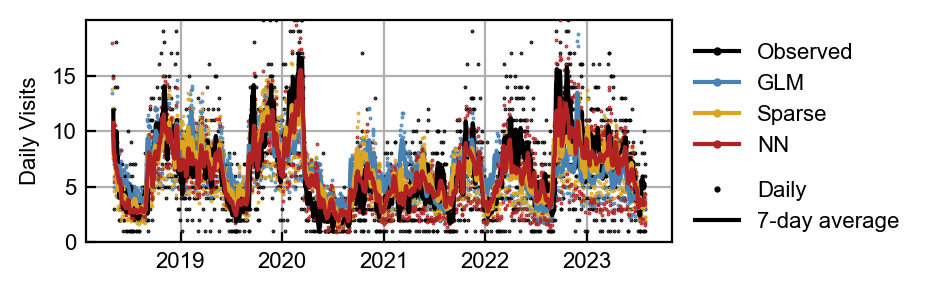

In [61]:
socio_var='svi'
score_df = predictions_figure(info, socio_var)
plt.savefig(os.path.join(os.environ['MODELS_DIR'], socio_var, 'predictions_comparison.pdf'), bbox_inches='tight')

score_df['params'] = score_df.apply(lambda row: f"{row['params_mean']:.0f} ({row['params_std']:.0f})", axis=1)
score_df['R2'] = score_df.apply(lambda row: f"{row['R2_mean']:.3f} ({row['R2_std']:.3f})", axis=1)
score_df['MAE'] = score_df.apply(lambda row: f"{row['MAE_mean']:.2f} ({row['MAE_std']:.2f})", axis=1)
print(score_df.set_index('model').loc[:, ['params', 'R2', 'MAE']].to_latex())